In [0]:
import pandas as pd                                                                 # Import pandas for data cleaning
import numpy as np                                                                  # Import Numpy for Maths functions
import matplotlib.pyplot as plt                                                     # Import Matplot for Viz functions
import seaborn as sns                                                               # Import Seaborn for visualization
import matplotlib.pyplot as plt                                                     # Import matplotlib library for visualization
import plotly.express as px                                                         # Import plotly library for visualization
import plotly.graph_objects as go

import pyspark.sql.functions as F                                                   # TableFunctions
from pyspark.sql import functions as F                                              # TableFunctions
from pyspark.sql.functions import col, when, expr                                   # TableFunctions
from pyspark.sql.functions import mean, min, max, stddev,count,sum as _sum          # MathsFunctions
from pyspark.sql.functions import to_date,year,month,datediff                       # DateFunctions
from pyspark.sql.functions import abs                                               # OtherFunctions

from pyspark.ml.feature import VectorAssembler                                      # Regression Analysis Functions
from pyspark.ml.regression import DecisionTreeRegressor                             # Regression Analysis Functions
from pyspark.ml.evaluation import RegressionEvaluator                               # Regression Analysis Functions
from pyspark.ml import Pipeline                                                     # Regression Analysis Functions
from pyspark.ml.feature import StringIndexer                                        # Classification Analysis Functions
from pyspark.ml.classification import DecisionTreeClassifier                        # Classification Analysis Functions
from pyspark.ml.evaluation import MulticlassClassificationEvaluator                 # Classification Analysis Functions
from pyspark.ml.feature import VectorAssembler

from sklearn.metrics import mean_squared_error, r2_score                            # Classification Analysis Functions
from sklearn.linear_model import LogisticRegression                                 # Classification Analysis Functions
from sklearn.impute import SimpleImputer                                            # Classification Analysis Functions
from sklearn.preprocessing import LabelEncoder                                      # Classification Analysis Functions
from sklearn.preprocessing import OneHotEncoder                                     # Classification Analysis Functions
from sklearn.preprocessing import StandardScaler                                    # Classification Analysis Functions
from sklearn.model_selection import train_test_split                                # Classification Analysis Functions
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report # Classification Analysis Functions
from sklearn.metrics import roc_curve, auc,f1_score                                 # Classification Analysis Functions
from sklearn.tree import DecisionTreeRegressor, plot_tree                           # Classification Analysis Functions

In [0]:
df = spark.read.table("boston_housing.boston_housing.bronze_bostanhousing")

In [0]:
# from pyspark.sql.functions import col, when, expr
# import pyspark.sql.functions as F

fact_cols = ["CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS","RAD","TAX","PTRATIO","B","LSTAT","MEDV"]
sentinel = 999999999

# Step 1: Force all columns to string
for col_name in fact_cols:
    df = df.withColumn(col_name, col(col_name).cast("string"))

# Step 2: Replace 'NA' with sentinel (string stage)
for col_name in fact_cols:
    df = df.withColumn(
        col_name,
        when((col(col_name).isNull()) | (col(col_name) == "NA"), str(sentinel)).otherwise(col(col_name))
    )

# Step 3: Cast to double
for col_name in fact_cols:
    df = df.withColumn(col_name, col(col_name).cast("double"))

# Step 4: Compute medians ignoring sentinel
medians = {}
for col_name in fact_cols:
    median_val = df.filter(col(col_name) != sentinel).approxQuantile(col_name, [0.5], 0.01)[0]
    medians[col_name] = median_val

# Step 5: Replace sentinel with median
for col_name in fact_cols:
    df = df.withColumn(
        col_name,
        when(col(col_name) == sentinel, medians[col_name]).otherwise(col(col_name))
    )

# Final cleaned DataFrame
display(df)

# df.write.mode("overwrite").option("overwriteSchema", "true").saveAsTable("boston_housing.silver.bostanhousing")

CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98,24.0
0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.9,9.14,21.6
0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.9,11.34,36.2
0.02985,0.0,2.18,0.0,0.458,6.43,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.6,12.43,22.9
0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.9,19.15,27.1
0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5
0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.1,18.9


Training Rows : 413
Testing Rows  : 93

Root Mean Squared Error (RMSE): 3.9692


CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,prediction,diff_prediction
0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98,24.0,25.97692307692308,-1.9769230769230788
0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.9,9.14,21.6,21.355782312925168,0.24421768707483338
0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,33.60645161290322,1.0935483870967815
0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,33.60645161290322,-0.20645161290322278
0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.9,11.34,36.2,33.60645161290322,2.5935483870967815
0.02985,0.0,2.18,0.0,0.458,6.43,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7,30.225000000000005,-1.5250000000000057
0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.6,12.43,22.9,21.355782312925168,1.5442176870748305
0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.9,19.15,27.1,15.970000000000002,11.129999999999999
0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5,15.970000000000002,0.5299999999999976
0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.1,18.9,15.970000000000002,2.929999999999996



Decision Tree Structure
DecisionTreeRegressionModel: uid=DecisionTreeRegressor_f361fedea2d4, depth=5, numNodes=59, numFeatures=13
  If (feature 5 <= 6.884)
   If (feature 12 <= 14.04)
    If (feature 7 <= 1.3720500000000002)
     If (feature 0 <= 9.55467)
      Predict: 50.0
     Else (feature 0 > 9.55467)
      If (feature 6 <= 93.69999999999999)
       Predict: 13.9
      Else (feature 6 > 93.69999999999999)
       Predict: 27.9
    Else (feature 7 > 1.3720500000000002)
     If (feature 5 <= 6.5205)
      If (feature 9 <= 222.5)
       Predict: 30.225000000000005
      Else (feature 9 > 222.5)
       Predict: 21.355782312925168
     Else (feature 5 > 6.5205)
      If (feature 9 <= 271.5)
       Predict: 30.16153846153846
      Else (feature 9 > 271.5)
       Predict: 25.97692307692308
   Else (feature 12 > 14.04)
    If (feature 0 <= 8.024135)
     If (feature 9 <= 306.0)
      If (feature 7 <= 3.92585)
       Predict: 20.741666666666664
      Else (feature 7 > 3.92585)
       Predi

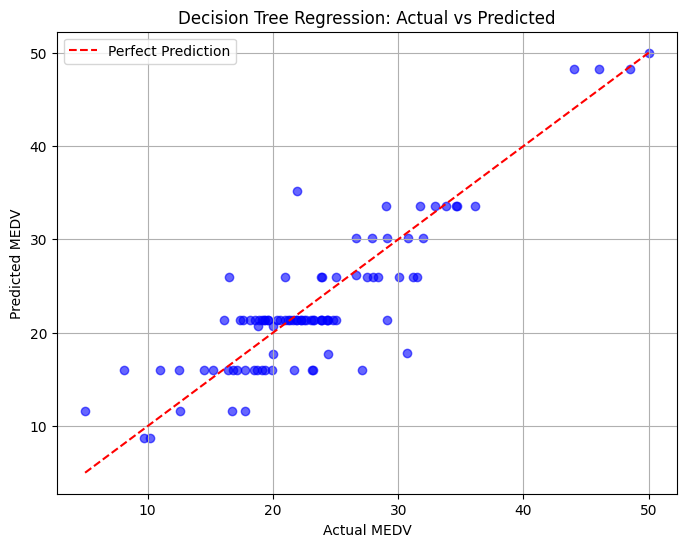

In [0]:
# ==========================================================
# Decision Tree Regression - Boston Housing Dataset
# Adds:
# 1. prediction
# 2. diff_prediction = MEDV - prediction
# ==========================================================

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Cleanup existing columns if present
# ----------------------------------------------------------

for c in ["prediction", "diff_prediction", "features"]:
    if c in df.columns:
        df = df.drop(c)

# ----------------------------------------------------------
# Define Features and Target
# ----------------------------------------------------------

feature_cols = [
    "CRIM",
    "ZN",
    "INDUS",
    "CHAS",
    "NOX",
    "RM",
    "AGE",
    "DIS",
    "RAD",
    "TAX",
    "PTRATIO",
    "B",
    "LSTAT"
]

target_col = "MEDV"

# ----------------------------------------------------------
# Assemble Features
# ----------------------------------------------------------

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# ----------------------------------------------------------
# Decision Tree Regressor
# ----------------------------------------------------------

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol=target_col,
    predictionCol="prediction",
    maxDepth=5,
    seed=42
)

# ----------------------------------------------------------
# Build Pipeline
# ----------------------------------------------------------

pipeline = Pipeline(
    stages=[assembler, dt]
)

# ----------------------------------------------------------
# Train-Test Split
# ----------------------------------------------------------

train_df, test_df = df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print(f"Training Rows : {train_df.count()}")
print(f"Testing Rows  : {test_df.count()}")

# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------

model = pipeline.fit(train_df)

# ----------------------------------------------------------
# Predict on Test Data
# ----------------------------------------------------------

predictions = model.transform(test_df)

# ----------------------------------------------------------
# Evaluate Model
# ----------------------------------------------------------

evaluator = RegressionEvaluator(
    labelCol=target_col,
    predictionCol="prediction",
    metricName="rmse"
)

rmse = evaluator.evaluate(predictions)

print(f"\nRoot Mean Squared Error (RMSE): {rmse:.4f}")

# ----------------------------------------------------------
# Predict on Full Dataset
# ----------------------------------------------------------

predictions_full = model.transform(df)

# Add difference column
df_final = (
    predictions_full
    .withColumn(
        "diff_prediction",
        col(target_col) - col("prediction")
    )
)

# ----------------------------------------------------------
# Display Full Dataset Results
# ----------------------------------------------------------

display(
    df_final.select(
        *feature_cols,
        target_col,
        "prediction",
        "diff_prediction"
    )
)

# ----------------------------------------------------------
# Save Final Table to silver
# ----------------------------------------------------------
(
    df_final.write
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable("boston_housing.silver.predictions")
)

print("Table saved: boston_housing.silver.predictions")

# ----------------------------------------------------------
# Decision Tree Structure
# ----------------------------------------------------------

tree_model = model.stages[-1]

print("\nDecision Tree Structure")
print("=" * 60)
print(tree_model.toDebugString)

# ----------------------------------------------------------
# Actual vs Predicted Visualization
# ----------------------------------------------------------

pdf = (
    predictions
    .select("MEDV", "prediction")
    .toPandas()
)

plt.figure(figsize=(8, 6))

plt.scatter(
    pdf["MEDV"],
    pdf["prediction"],
    alpha=0.6,
    color="blue"
)

plt.plot(
    [pdf["MEDV"].min(), pdf["MEDV"].max()],
    [pdf["MEDV"].min(), pdf["MEDV"].max()],
    color="red",
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Decision Tree Regression: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.show()



Classification Accuracy: 0.8553


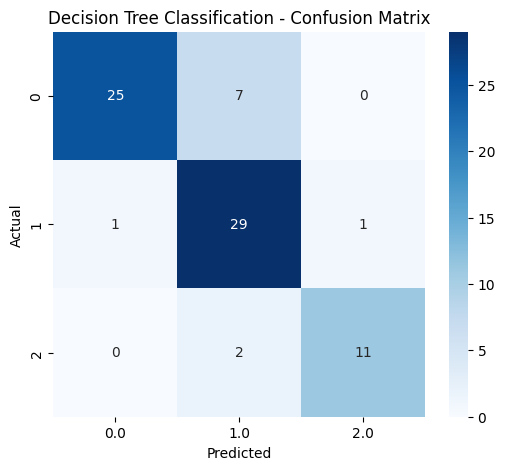

CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,prediction,diff_prediction,PriceCategory,class_prediction
0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.09,1.0,296.0,15.3,396.9,4.98,24.0,25.97692307692308,-1.9769230769230788,1,1.0
0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.9,9.14,21.6,21.355782312925168,0.24421768707483338,1,1.0
0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7,33.60645161290322,1.0935483870967815,2,2.0
0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4,33.60645161290322,-0.20645161290322278,2,2.0
0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.9,11.34,36.2,33.60645161290322,2.5935483870967815,2,2.0
0.02985,0.0,2.18,0.0,0.458,6.43,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7,30.225000000000005,-1.5250000000000057,1,1.0
0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.6,12.43,22.9,21.355782312925168,1.5442176870748305,1,1.0
0.14455,12.5,7.87,0.0,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.9,19.15,27.1,15.970000000000002,11.129999999999999,1,1.0
0.21124,12.5,7.87,0.0,0.524,5.631,100.0,6.0821,5.0,311.0,15.2,386.63,29.93,16.5,15.970000000000002,0.5299999999999976,0,0.0
0.17004,12.5,7.87,0.0,0.524,6.004,85.9,6.5921,5.0,311.0,15.2,386.71,17.1,18.9,15.970000000000002,2.929999999999996,0,0.0



Table saved successfully:
boston_housing.silver.classification


In [0]:
# ==========================================================
# DECISION TREE CLASSIFICATION
# Add classification results to df_final
# Save as: boston_housing.silver.classification
# ==========================================================

from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Remove old classification columns if rerunning
# ----------------------------------------------------------

for c in ["PriceCategory", "class_prediction"]:
    if c in df_final.columns:
        df_final = df_final.drop(c)

# ----------------------------------------------------------
# Create Target Column
# ----------------------------------------------------------

df_class = (
    df_final
    .withColumn(
        "PriceCategory",
        when(col("MEDV") < 20, 0)
        .when((col("MEDV") >= 20) & (col("MEDV") < 30), 1)
        .otherwise(2)
    )
)

# ----------------------------------------------------------
# Features
# ----------------------------------------------------------

feature_cols = [
    "CRIM","ZN","INDUS","CHAS","NOX",
    "RM","AGE","DIS","RAD","TAX",
    "PTRATIO","B","LSTAT"
]

target_col = "PriceCategory"

# ----------------------------------------------------------
# Classification Pipeline
# ----------------------------------------------------------

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="class_features"
)

dt_classifier = DecisionTreeClassifier(
    featuresCol="class_features",
    labelCol=target_col,
    predictionCol="class_prediction",
    maxDepth=5,
    seed=42
)

pipeline = Pipeline(
    stages=[assembler, dt_classifier]
)

# ----------------------------------------------------------
# Train/Test Split
# ----------------------------------------------------------

train_df, test_df = df_class.randomSplit(
    [0.8, 0.2],
    seed=42
)

# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------

model = pipeline.fit(train_df)

# ----------------------------------------------------------
# Test Predictions
# ----------------------------------------------------------

predictions = model.transform(test_df)

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

evaluator = MulticlassClassificationEvaluator(
    labelCol=target_col,
    predictionCol="class_prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("=" * 60)
print(f"Classification Accuracy: {accuracy:.4f}")
print("=" * 60)

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

pdf = (
    predictions
    .select("PriceCategory", "class_prediction")
    .toPandas()
)

conf_matrix = pd.crosstab(
    pdf["PriceCategory"],
    pdf["class_prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Classification - Confusion Matrix")
plt.show()

# ----------------------------------------------------------
# Score Full Dataset
# ----------------------------------------------------------

if "class_prediction" in df_class.columns:
    df_class = df_class.drop("class_prediction")

final_classification_df = model.transform(df_class)

# ----------------------------------------------------------
# Select Final Columns
# Includes:
# - Regression Results
# - Classification Results
# ----------------------------------------------------------

final_classification_df = final_classification_df.select(
    *feature_cols,
    "MEDV",
    "prediction",            # Regression prediction
    "diff_prediction",       # Regression error
    "PriceCategory",         # Actual Class
    "class_prediction"       # Predicted Class
)

# ----------------------------------------------------------
# Display Results
# ----------------------------------------------------------

display(final_classification_df)

# ----------------------------------------------------------
# Save to Silver Layer
# ----------------------------------------------------------

(
    final_classification_df
    .write
    .format("delta")
    .mode("overwrite")
    .saveAsTable("boston_housing.silver.Predictions")
)

print("\nTable saved successfully:")
print("boston_housing.silver.classification")